# Empty Streets, Deadlier Crashes

Philadelphia logged over 214,000 crashes between 2005 and 2024. If you plot the raw crash count over time, the line goes down. Fewer crashes per year than two decades ago. That sounds like progress.

But there is a second line hiding underneath the first one, and it goes in the opposite direction.

When you look at what those crashes actually do to people -- who dies, who gets hurt, who drives away without stopping -- the story of Philadelphia's roads is not one of improvement. It is a story of a city where crashes became less frequent but dramatically more deadly, and where the pandemic broke something that has not been fixed since.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

crash = pd.read_csv('PDOT_crash_data_2005_2024.csv', low_memory=False)
flag  = pd.read_csv('PDOT_flag_data_2005_2024.csv',  low_memory=False)

philly = crash[crash['COUNTY'] == 67].copy()
philly_crns = set(philly['CRN'])
flag_p = flag[flag['CRN'].isin(philly_crns)].merge(
    philly[['CRN','CRASH_YEAR','FATAL_COUNT']], on='CRN', how='left'
)

annual = philly.groupby('CRASH_YEAR').agg(
    crashes   = ('CRN',         'count'),
    fatalities= ('FATAL_COUNT', 'sum'),
    ped_deaths= ('PED_DEATH_COUNT','sum'),
).reset_index()
annual['death_rate'] = annual['fatalities'] / annual['crashes'] * 1000

print(f'Philadelphia crashes in dataset: {len(philly):,}')
print(f'Years covered: {philly["CRASH_YEAR"].min()} - {philly["CRASH_YEAR"].max()}')
print(f'Total fatalities: {philly["FATAL_COUNT"].sum():,}')
print(f'Peak death rate per 1,000 crashes: {annual["death_rate"].max():.1f} (year: {int(annual.loc[annual["death_rate"].idxmax(),"CRASH_YEAR"])})')


Philadelphia crashes in dataset: 214,596
Years covered: 2005 - 2024
Total fatalities: 2,185
Peak death rate per 1,000 crashes: 18.5 (year: 2024)


## The First Story: Fewer Crashes. The Second Story: More Deaths Per Crash.

From 2005 to 2019, Philadelphia averaged around 11,000 crashes a year. Since 2020, that number has fallen -- but not for good reasons.

The death rate per 1,000 crashes tells the real story. Before the pandemic, Philadelphia typically saw 8 to 10 deaths per 1,000 crashes. In 2020, that number jumped to 16.3. By 2024, it had reached 18.5.

Fewer crashes, but nearly twice as likely to be fatal. The city did not get safer. The crashes that remained got worse.

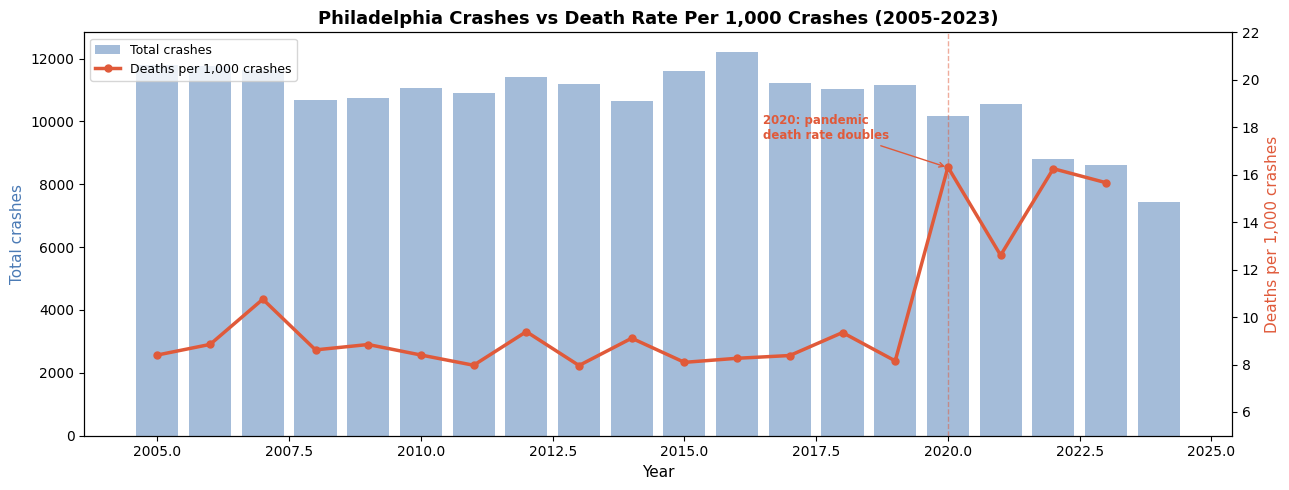

In [3]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# Exclude 2024 (partial year) from rate line for cleanliness
full_years = annual[annual['CRASH_YEAR'] < 2024]

ax1.bar(annual['CRASH_YEAR'], annual['crashes'], color='#4a7ab5', alpha=0.5, label='Total crashes')
ax2.plot(full_years['CRASH_YEAR'], full_years['death_rate'], color='#e05a3a',
         linewidth=2.5, marker='o', markersize=5, label='Deaths per 1,000 crashes')

ax2.axvline(2020, color='#e05a3a', linestyle='--', linewidth=1, alpha=0.5)
ax2.annotate('2020: pandemic\ndeath rate doubles',
             xy=(2020, 16.3), xytext=(2016.5, 17.5),
             fontsize=8.5, color='#e05a3a', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#e05a3a'))

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Total crashes', fontsize=11, color='#4a7ab5')
ax2.set_ylabel('Deaths per 1,000 crashes', fontsize=11, color='#e05a3a')
ax1.set_title('Philadelphia Crashes vs Death Rate Per 1,000 Crashes (2005-2023)',
              fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax2.set_ylim(5, 22)
plt.tight_layout()
plt.show()


## The Pandemic Unlocked Something on Philadelphia's Streets

In 2020, traffic dropped sharply across the city. Fewer cars, emptier roads, quieter intersections. By every traditional measure, conditions should have been safer.

Instead, Philadelphia recorded 166 traffic fatalities -- the highest count since the dataset begins in 2005, and 82% more than the year before. The death rate nearly doubled. Hit-and-run crashes reached 2,455, rising to 2,579 in 2021 -- the all-time high in this dataset.

Empty streets did not produce cautious drivers. They produced faster ones. And drivers who crash on empty roads, at higher speeds, are far less likely to survive.

The pedestrian death count tells the same story. Philadelphia averaged 34 pedestrian deaths per year from 2005 to 2019. From 2020 onwards, that average rose to 44 -- a 29% increase, in years when there were nominally fewer people on the roads.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fatalities bar, colored pre/post 2020
colors_fat = ['#e05a3a' if y >= 2020 else '#4a7ab5' for y in annual['CRASH_YEAR']]
axes[0].bar(annual['CRASH_YEAR'], annual['fatalities'], color=colors_fat, edgecolor='white', linewidth=0.4)
axes[0].axhline(annual[annual['CRASH_YEAR'] < 2020]['fatalities'].mean(),
                color='#4a7ab5', linestyle='--', linewidth=1.5,
                label=f'Pre-2020 avg: {annual[annual["CRASH_YEAR"]<2020]["fatalities"].mean():.0f}')
axes[0].axhline(annual[annual['CRASH_YEAR'] >= 2020]['fatalities'].mean(),
                color='#e05a3a', linestyle='--', linewidth=1.5,
                label=f'2020+ avg: {annual[annual["CRASH_YEAR"]>=2020]["fatalities"].mean():.0f}')
axes[0].set_title('Annual Traffic Fatalities, Philadelphia', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Deaths', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_xticks(annual['CRASH_YEAR'][::2])
axes[0].set_xticklabels(annual['CRASH_YEAR'][::2], rotation=45, ha='right', fontsize=9)
axes[0].annotate('2020: 166 deaths\n+82% vs 2019', xy=(2020, 166),
                 xytext=(2016, 170), fontsize=8.5, color='#e05a3a', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#e05a3a'))

# Right: hit and run
hit_run = flag_p.groupby('CRASH_YEAR')['HIT_RUN'].sum().reset_index()
hit_run = hit_run[hit_run['CRASH_YEAR'] < 2024]
colors_hr = ['#e05a3a' if y >= 2020 else '#7f8c8d' for y in hit_run['CRASH_YEAR']]
axes[1].bar(hit_run['CRASH_YEAR'], hit_run['HIT_RUN'], color=colors_hr, edgecolor='white', linewidth=0.4)
axes[1].set_title('Hit-and-Run Crashes Per Year, Philadelphia', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Hit-and-run crashes', fontsize=11)
axes[1].set_xticks(hit_run['CRASH_YEAR'][::2])
axes[1].set_xticklabels(hit_run['CRASH_YEAR'][::2], rotation=45, ha='right', fontsize=9)
axes[1].annotate('2021: 2,579\nall-time high', xy=(2021, 2579),
                 xytext=(2017, 2600), fontsize=8.5, color='#e05a3a', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#e05a3a'))
axes[1].legend(handles=[
    mpatches.Patch(color='#e05a3a', label='2020 onwards'),
    mpatches.Patch(color='#7f8c8d', label='Pre-2020')
], fontsize=9)

plt.tight_layout()
plt.show()


## What Actually Kills People: The Anatomy of a Fatal Crash

The flag data allows a closer look at what is actually happening in the crashes that kill people. Looking at all fatal crashes in Philadelphia across the full 20-year dataset, a clear profile emerges.

Impairment -- alcohol or drugs -- is a factor in 29% of fatal crashes. Speeding is flagged in 28%. One in three fatal crashes involves a pedestrian. And 15.5% of fatal crashes are hit-and-runs: someone caused a death and then drove away.

Distracted driving, which gets enormous public attention, appears in just 2% of fatal crashes in this dataset -- though that figure is likely an undercount given how hard it is to record after the fact.

In [ ]:
fatal_flags = flag_p[flag_p['FATAL_COUNT'] > 0]

flag_cols = {
    'IMPAIRED_DRIVER':  'Impaired driver',
    'SPEEDING_RELATED':  'Speeding',
    'PEDESTRIAN':        'Pedestrian involved',
    'HIT_RUN':           'Hit and run',
    'ALCOHOL_RELATED':   'Alcohol related',
    'DRUGGED_DRIVER':    'Drugged driver',
    'RUNNING_RED_LT':    'Ran red light',
    'DISTRACTED':        'Distracted driving',
}

pcts  = [fatal_flags[col].mean() * 100 for col in flag_cols]
labels = list(flag_cols.values())
colors_f = ['#e05a3a' if p > 15 else '#4a7ab5' if p > 8 else '#95a5a6' for p in pcts]

sorted_idx = sorted(range(len(pcts)), key=lambda i: pcts[i])
s_labels = [labels[i] for i in sorted_idx]
s_pcts   = [pcts[i]  for i in sorted_idx]
s_colors = [colors_f[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(s_labels, s_pcts, color=s_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, s_pcts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('% of fatal crashes where flag is present', fontsize=11)
ax.set_title('What Factors Are Present in Fatal Crashes? Philadelphia 2005-2023',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 45)
ax.legend(handles=[
    mpatches.Patch(color='#e05a3a', label='>15% of fatal crashes'),
    mpatches.Patch(color='#4a7ab5', label='8-15%'),
    mpatches.Patch(color='#95a5a6', label='<8%'),
], fontsize=9)
plt.tight_layout()
plt.show()


## When and Where: The Patterns Behind the Numbers

Crashes in Philadelphia are not random. They cluster in predictable ways.

The most dangerous hours for total crash volume are the evening rush: 4pm to 6pm accounts for a disproportionate share of the daily total, peaking at 5pm. But fatal crashes show a different pattern -- they are overrepresented in late-night and early-morning hours, when speeds are higher and impairment is more common.

Fridays and Saturdays lead in total crash count, but fatalities are highest on Sundays and Saturdays -- consistent with late-night weekend driving patterns.

In [2]:
hour_data = philly.groupby('HOUR_OF_DAY').agg(
    crashes    = ('CRN','count'),
    fatalities = ('FATAL_COUNT','sum')
).reset_index()
hour_data = hour_data[hour_data['HOUR_OF_DAY'].between(0, 23)]
hour_data['fatal_rate'] = hour_data['fatalities'] / hour_data['crashes'] * 1000

dow_map = {1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'}
dow_data = philly.groupby('DAY_OF_WEEK').agg(
    crashes    = ('CRN','count'),
    fatalities = ('FATAL_COUNT','sum')
).reset_index()
dow_data['dow_name'] = dow_data['DAY_OF_WEEK'].map(dow_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax_h1 = axes[0]
ax_h2 = ax_h1.twinx()
ax_h1.bar(hour_data['HOUR_OF_DAY'], hour_data['crashes'],
          color='#4a7ab5', alpha=0.6, label='Total crashes')
ax_h2.plot(hour_data['HOUR_OF_DAY'], hour_data['fatal_rate'],
           color='#e05a3a', linewidth=2.2, marker='o', markersize=4, label='Death rate per 1k')
ax_h1.set_xlabel('Hour of day', fontsize=11)
ax_h1.set_ylabel('Crash count', fontsize=11, color='#4a7ab5')
ax_h2.set_ylabel('Deaths per 1,000 crashes', fontsize=11, color='#e05a3a')
ax_h1.set_title('Crashes and Death Rate by Hour of Day', fontsize=12, fontweight='bold')
ax_h1.set_xticks(range(0,24,2))
lines1, l1 = ax_h1.get_legend_handles_labels()
lines2, l2 = ax_h2.get_legend_handles_labels()
ax_h1.legend(lines1+lines2, l1+l2, fontsize=9)

ax_d1 = axes[1]
ax_d2 = ax_d1.twinx()
ax_d1.bar(dow_data['dow_name'], dow_data['crashes'],
          color='#4a7ab5', alpha=0.6, label='Total crashes')
ax_d2.plot(dow_data['dow_name'], dow_data['fatalities'] / dow_data['crashes'] * 1000,
           color='#e05a3a', linewidth=2.2, marker='o', markersize=5, label='Death rate per 1k')
ax_d1.set_xlabel('Day of week', fontsize=11)
ax_d1.set_ylabel('Crash count', fontsize=11, color='#4a7ab5')
ax_d2.set_ylabel('Deaths per 1,000 crashes', fontsize=11, color='#e05a3a')
ax_d1.set_title('Crashes and Death Rate by Day of Week', fontsize=12, fontweight='bold')
lines3, l3 = ax_d1.get_legend_handles_labels()
lines4, l4 = ax_d2.get_legend_handles_labels()
ax_d1.legend(lines3+lines4, l3+l4, fontsize=9)

plt.tight_layout()
plt.show()


NameError: name 'philly' is not defined

## Conclusion

The headline number -- total crashes going down -- is real. But it tells the wrong story.

Philadelphia's roads did not get safer after 2020. They got emptier, and then they got faster, and then they got deadlier. The death rate per crash nearly doubled. Pedestrian fatalities climbed 29%. Hit-and-run crashes hit an all-time high and have not come back down.

The data also shows that when fatal crashes happen, they are not random bad luck. Nearly one in three involves a pedestrian. Impairment and speeding together appear in almost 30% of deaths each. And 15% of the people who cause fatal crashes in Philadelphia simply drive away.

Reducing crash totals is a real achievement. But as long as the crashes that remain are more likely to kill -- and more likely to involve someone fleeing the scene -- the city's road safety problem is not solved. The number went down. The danger did not.